# IEMOCAP → Мультимодальный датасет

Пайплайн:
1. Парсинг `EmoEvaluation` → метаданные (ID, эмоция, VAD, временные метки)
2. Фильтрация по **7 классам** совместимым с RAVDESS (без `calm` — нет в IEMOCAP; без `fru` — нет в RAVDESS; без `xxx`)
3. Извлечение **аудио** признаков — log-mel спектрограмма из `sentences/wav/`
4. Извлечение **видео** кадров — из `dialog/avi/DivX/` по временным меткам
5. Извлечение **текста** — из `dialog/transcriptions/`
6. `IEMOCAPDataset` + Leave-One-Session-Out сплиты
7. Сохранение датасета на диск

**Маппинг эмоций IEMOCAP → RAVDESS:**

| IEMOCAP | RAVDESS | idx |
|---------|---------|-----|
| `neu`   | neutral (01) | 0 |
| `hap`, `exc` | happy (03) | 1 |
| `sad`   | sad (04) | 2 |
| `ang`   | angry (05) | 3 |
| `fea`   | fearful (06) | 4 |
| `dis`   | disgust (07) | 5 |
| `sur`   | surprised (08) | 6 |
| `fru`, `xxx` | — | удаляются |

In [9]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import librosa
import cv2
import matplotlib.pyplot as plt
from tqdm import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: mps


In [10]:
# ── Конфигурация ──────────────────────────────────────────────────────────────
IEMOCAP_ROOT = '../datasets/IEMOCAP_full_release'
SAVE_DIR     = '../datasets/iemocap_processed'
SESSIONS     = [f'Session{i}' for i in range(1, 6)]

# Маппинг IEMOCAP → RAVDESS-совместимые имена.
# calm (RAVDESS 02) отсутствует в IEMOCAP.
# fru (frustration) и xxx не имеют аналога в RAVDESS → None → будут удалены.
EMOTION_MAP = {
    'neu': 'neutral',    # RAVDESS 01
    'hap': 'happy',      # RAVDESS 03
    'exc': 'happy',      # excited → happy
    'sad': 'sad',        # RAVDESS 04
    'ang': 'angry',      # RAVDESS 05
    'fea': 'fearful',    # RAVDESS 06
    'dis': 'disgust',    # RAVDESS 07
    'sur': 'surprised',  # RAVDESS 08
    # fru, xxx → None (автоматически удаляются через dropna)
}
LABEL2IDX = {
    'neutral':   0,   # RAVDESS 01
    'happy':     1,   # RAVDESS 03
    'sad':       2,   # RAVDESS 04
    'angry':     3,   # RAVDESS 05
    'fearful':   4,   # RAVDESS 06
    'disgust':   5,   # RAVDESS 07
    'surprised': 6,   # RAVDESS 08
}
IDX2LABEL = {v: k for k, v in LABEL2IDX.items()}

# Аудио
SAMPLE_RATE   = 16_000
AUDIO_DURATION = 4.0          # секунд (паддинг / обрезка)
N_MELS        = 128
HOP_LENGTH    = 160            # 10 ms при 16 kHz
N_FFT         = 512

# Видео
N_FRAMES      = 8              # кадров на реплику
FRAME_SIZE    = (112, 112)     # H × W

os.makedirs(SAVE_DIR, exist_ok=True)
print('Конфигурация загружена.')

Конфигурация загружена.


## 1. Парсинг EmoEvaluation

In [11]:
def parse_emo_eval(filepath: str) -> list[dict]:
    """
    Читает файл EmoEvaluation и возвращает список словарей.
    Формат строки: [start - end]\tutt_id\temotion\t[V, A, D]
    """
    records = []
    pattern = re.compile(
        r'\[([\d.]+)\s*-\s*([\d.]+)\]\s+'
        r'(\S+)\s+'
        r'(\w+)\s+'
        r'\[([\d.,\s]+)\]'
    )
    with open(filepath, 'r') as f:
        for line in f:
            m = pattern.match(line.strip())
            if not m:
                continue
            start, end = float(m.group(1)), float(m.group(2))
            utt_id     = m.group(3)
            emotion    = m.group(4)
            vad        = [float(x) for x in m.group(5).split(',')]
            # speaker: последний символ перед номером (F / M)
            speaker    = re.search(r'_(F|M)\d+$', utt_id)
            speaker    = speaker.group(1) if speaker else 'U'
            records.append({
                'utterance_id': utt_id,
                'start':        start,
                'end':          end,
                'emotion_raw':  emotion,
                'valence':      vad[0],
                'activation':   vad[1],
                'dominance':    vad[2],
                'speaker':      speaker,
            })
    return records


def collect_metadata(root: str, sessions: list[str]) -> pd.DataFrame:
    """Собирает метаданные по всем сессиям и диалогам."""
    all_records = []
    for session in sessions:
        emo_dir = os.path.join(root, session, 'dialog', 'EmoEvaluation')
        for fname in sorted(os.listdir(emo_dir)):
            if not fname.endswith('.txt'):
                continue
            dialog_id = fname.replace('.txt', '')
            records   = parse_emo_eval(os.path.join(emo_dir, fname))
            for r in records:
                r['session'] = session
                r['dialog']  = dialog_id
            all_records.extend(records)
    return pd.DataFrame(all_records)


meta = collect_metadata(IEMOCAP_ROOT, SESSIONS)
print(f'Всего реплик: {len(meta)}')
print(meta['emotion_raw'].value_counts().to_string())

Всего реплик: 10039
emotion_raw
xxx    2507
fru    1849
neu    1708
ang    1103
sad    1084
exc    1041
hap     595
sur     107
fea      40
oth       3
dis       2


## 2. Фильтрация и балансировка классов

После фильтрации: 5680 реплик
emotion
neutral      1708
happy        1636
angry        1103
sad          1084
surprised     107
fearful        40
disgust         2


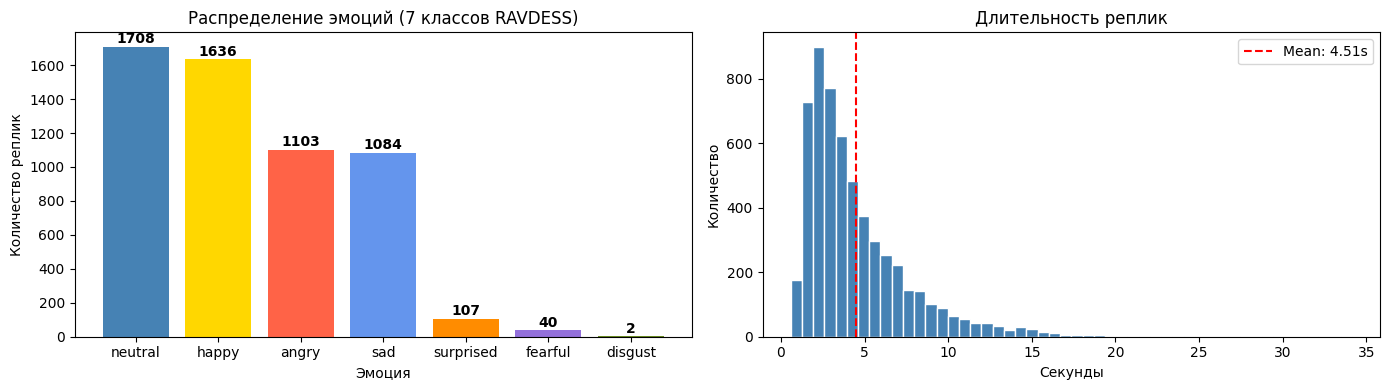


Длительность: min=0.58s  mean=4.51s  max=34.14s


In [12]:
# Применяем маппинг эмоций
meta['emotion'] = meta['emotion_raw'].map(EMOTION_MAP)
meta = meta.dropna(subset=['emotion']).copy()
meta['label'] = meta['emotion'].map(LABEL2IDX)

# Проверяем, что аудио-файл существует
def audio_path(row: pd.Series) -> str:
    return os.path.join(
        IEMOCAP_ROOT, row['session'], 'sentences', 'wav',
        row['dialog'], f"{row['utterance_id']}.wav"
    )

meta['audio_path'] = meta.apply(audio_path, axis=1)
meta = meta[meta['audio_path'].apply(os.path.exists)].reset_index(drop=True)

print(f'После фильтрации: {len(meta)} реплик')
print(meta['emotion'].value_counts().to_string())

# Визуализация распределения классов
EMO_COLORS = {
    'neutral':   'steelblue',
    'happy':     'gold',
    'sad':       'cornflowerblue',
    'angry':     'tomato',
    'fearful':   'mediumpurple',
    'disgust':   'olivedrab',
    'surprised': 'darkorange',
}
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

counts = meta['emotion'].value_counts()
bar_colors = [EMO_COLORS.get(e, 'gray') for e in counts.index]
axes[0].bar(counts.index, counts.values, color=bar_colors)
axes[0].set_title('Распределение эмоций (7 классов RAVDESS)')
axes[0].set_xlabel('Эмоция')
axes[0].set_ylabel('Количество реплик')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

durations = meta['end'] - meta['start']
axes[1].hist(durations, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(durations.mean(), color='red', linestyle='--', label=f'Mean: {durations.mean():.2f}s')
axes[1].set_title('Длительность реплик')
axes[1].set_xlabel('Секунды')
axes[1].set_ylabel('Количество')
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'dataset_stats.png'), dpi=150)
plt.show()

print(f'\nДлительность: min={durations.min():.2f}s  mean={durations.mean():.2f}s  max={durations.max():.2f}s')

## 3. Текстовые данные (транскрипции)

In [13]:
def load_transcriptions(root: str, session: str, dialog: str) -> dict[str, str]:
    """Возвращает {utterance_id: text} для одного диалога."""
    path = os.path.join(root, session, 'dialog', 'transcriptions', f'{dialog}.txt')
    result = {}
    if not os.path.exists(path):
        return result
    with open(path, 'r') as f:
        for line in f:
            # Формат: Ses01F_impro01_F000 [006.29-008.24]: Excuse me.
            m = re.match(r'(\S+)\s+\[[\d.]+-[\d.]+\]:\s*(.*)', line.strip())
            if m:
                result[m.group(1)] = m.group(2).strip()
    return result


# Собираем транскрипции для всех реплик
texts = {}
for session in tqdm(SESSIONS, desc='Транскрипции'):
    dialogs = meta[meta['session'] == session]['dialog'].unique()
    for dialog in dialogs:
        trans = load_transcriptions(IEMOCAP_ROOT, session, dialog)
        texts.update(trans)

meta['text'] = meta['utterance_id'].map(texts).fillna('')
coverage = (meta['text'] != '').mean() * 100
print(f'Транскрипций найдено: {coverage:.1f}%')
print(meta[['utterance_id', 'emotion', 'text']].head(5).to_string(index=False))

Транскрипции: 100%|██████████| 5/5 [00:00<00:00, 116.47it/s]

Транскрипций найдено: 100.0%
       utterance_id emotion                                        text
Ses01F_impro01_F000 neutral                                  Excuse me.
Ses01F_impro01_F001 neutral                                       Yeah.
Ses01F_impro01_F002 neutral                         Is there a problem?
Ses01F_impro01_F005 neutral Well what's the problem?  Let me change it.
Ses01F_impro01_F012   angry                      That's out of control.


## 4. Аудио признаки — Log-Mel спектрограммы

Log-mel shape: (128, 401)  (n_mels=128, T=401)


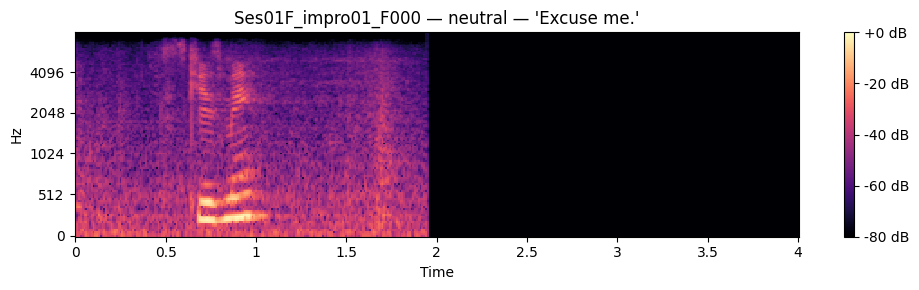

In [14]:
def extract_log_mel(wav_path: str,
                    sr: int       = SAMPLE_RATE,
                    duration: float = AUDIO_DURATION,
                    n_mels: int   = N_MELS,
                    n_fft: int    = N_FFT,
                    hop: int      = HOP_LENGTH) -> np.ndarray:
    """
    Возвращает log-mel спектрограмму формы (n_mels, T).
    Длина T фиксирована: duration * sr / hop_length.
    """
    target_len = int(duration * sr)
    y, _ = librosa.load(wav_path, sr=sr, mono=True)

    # Паддинг или обрезка до нужной длины
    if len(y) < target_len:
        y = np.pad(y, (0, target_len - len(y)))
    else:
        y = y[:target_len]

    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                          n_fft=n_fft, hop_length=hop)
    log_mel = librosa.power_to_db(mel, ref=np.max)
    return log_mel.astype(np.float32)   # (128, T)


# Проверка на одном примере
sample_row = meta.iloc[0]
sample_mel  = extract_log_mel(sample_row['audio_path'])
print(f'Log-mel shape: {sample_mel.shape}  (n_mels={sample_mel.shape[0]}, T={sample_mel.shape[1]})')

plt.figure(figsize=(10, 3))
librosa.display.specshow(sample_mel, sr=SAMPLE_RATE, hop_length=HOP_LENGTH,
                          x_axis='time', y_axis='mel', cmap='magma')
plt.colorbar(format='%+2.0f dB')
plt.title(f"{sample_row['utterance_id']} — {sample_row['emotion']} — {sample_row['text']!r}")
plt.tight_layout()
plt.show()

## 5. Видео признаки — кадры лица из AVI

Video frames shape: (8, 112, 112, 3)  (N, H, W, C)


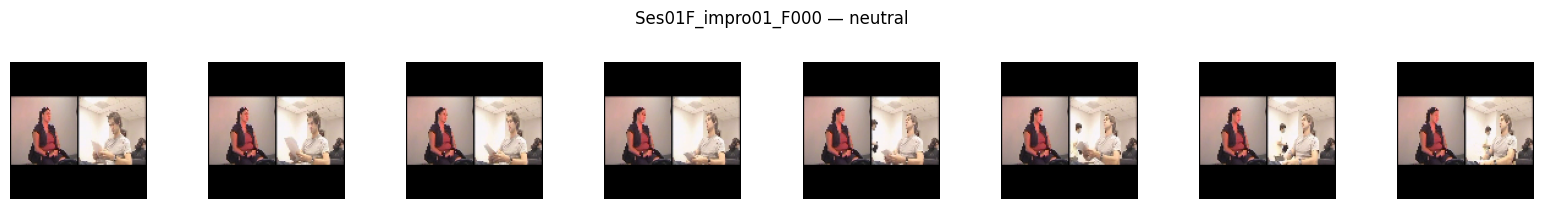

In [15]:
def extract_frames(avi_path: str,
                   start: float,
                   end: float,
                   n_frames: int = N_FRAMES,
                   frame_size: tuple[int,int] = FRAME_SIZE) -> np.ndarray | None:
    """
    Из диалогового AVI вырезает сегмент [start, end],
    равномерно сэмплирует n_frames кадров.
    Возвращает массив (n_frames, H, W, 3) uint8 в RGB, или None при ошибке.
    """
    cap = cv2.VideoCapture(avi_path)
    if not cap.isOpened():
        return None

    fps        = cap.get(cv2.CAP_PROP_FPS) or 25.0
    start_f    = int(start * fps)
    end_f      = int(end   * fps)
    total_seg  = max(end_f - start_f, 1)

    # Равномерные временные точки внутри сегмента
    frame_indices = np.linspace(start_f, end_f - 1, n_frames, dtype=int)

    frames = []
    for fi in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, fi)
        ret, frame = cap.read()
        if not ret:
            # Повторяем последний удачный кадр
            frame = frames[-1] if frames else np.zeros((*frame_size, 3), dtype=np.uint8)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, frame_size)
        frames.append(frame)

    cap.release()
    return np.stack(frames)  # (N, H, W, 3)


def avi_path(row: pd.Series, root: str) -> str:
    return os.path.join(
        root, row['session'], 'dialog', 'avi', 'DivX',
        f"{row['dialog']}.avi"
    )


# Проверка на одном примере
sample_avi   = avi_path(sample_row, IEMOCAP_ROOT)
sample_video = extract_frames(sample_avi, sample_row['start'], sample_row['end'])

if sample_video is not None:
    print(f'Video frames shape: {sample_video.shape}  (N, H, W, C)')
    fig, axes = plt.subplots(1, N_FRAMES, figsize=(16, 2))
    for i, ax in enumerate(axes):
        ax.imshow(sample_video[i])
        ax.axis('off')
    plt.suptitle(f"{sample_row['utterance_id']} — {sample_row['emotion']}", y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('AVI файл не найден — видео-модальность будет пропущена.')

## 6. Предварительная обработка и сохранение признаков на диск

Для каждой реплики извлекаем признаки и сохраняем в `npz`-файл:  
`iemocap_processed/{session}/{utterance_id}.npz`  
Содержит: `audio` (128×T), `video` (N×H×W×3), `label` (int).

In [16]:
FORCE_REEXTRACT = False   # True — перезаписать уже существующие файлы

errors = []

for session in SESSIONS:
    os.makedirs(os.path.join(SAVE_DIR, session), exist_ok=True)

session_groups = meta.groupby('session')

for session, group in session_groups:
    print(f'\n── {session} ({len(group)} реплик) ──')
    for _, row in tqdm(group.iterrows(), total=len(group), desc=session):
        out_path = os.path.join(SAVE_DIR, session, f"{row['utterance_id']}.npz")
        if os.path.exists(out_path) and not FORCE_REEXTRACT:
            continue

        # Аудио
        try:
            audio = extract_log_mel(row['audio_path'])
        except Exception as e:
            errors.append({'id': row['utterance_id'], 'err': str(e)})
            continue

        # Видео
        avi = avi_path(row, IEMOCAP_ROOT)
        if os.path.exists(avi):
            video = extract_frames(avi, row['start'], row['end'])
        else:
            video = np.zeros((N_FRAMES, *FRAME_SIZE, 3), dtype=np.uint8)

        if video is None:
            video = np.zeros((N_FRAMES, *FRAME_SIZE, 3), dtype=np.uint8)

        np.savez_compressed(
            out_path,
            audio = audio,             # float32 (128, T)
            video = video,             # uint8   (N, H, W, 3)
            label = np.int64(row['label']),
        )

print(f'\nГотово! Ошибок: {len(errors)}')
if errors:
    print(pd.DataFrame(errors).head(10).to_string(index=False))


── Session1 (1123 реплик) ──


Session1: 100%|██████████| 1123/1123 [04:45<00:00,  3.93it/s]



── Session2 (1049 реплик) ──


Session2: 100%|██████████| 1049/1049 [04:23<00:00,  3.97it/s]



── Session3 (1182 реплик) ──


...


── Session4 (1057 реплик) ──


Session4: 100%|██████████| 1057/1057 [04:27<00:00,  3.95it/s]



── Session5 (1269 реплик) ──


Session5: 100%|██████████| 1269/1269 [05:41<00:00,  3.71it/s]


Готово! Ошибок: 0


## 7. Dataset класс

In [17]:
import torchvision.transforms as T


class IEMOCAPDataset(Dataset):
    """
    Мультимодальный датасет IEMOCAP.

    Возвращает словарь:
        audio  : Tensor (1, n_mels, T)      — log-mel спектрограмма
        video  : Tensor (N, 3, H, W)        — нормализованные кадры
        text   : str                        — транскрипция
        label  : Tensor scalar (int64)      — 0..3
        utt_id : str
    """

    VIDEO_MEAN = [0.485, 0.456, 0.406]
    VIDEO_STD  = [0.229, 0.224, 0.225]

    def __init__(self,
                 metadata:   pd.DataFrame,
                 save_dir:   str,
                 augment:    bool = False):
        self.meta     = metadata.reset_index(drop=True)
        self.save_dir = save_dir
        self.augment  = augment

        self.video_tf = T.Compose([
            T.ToTensor(),
            T.Normalize(self.VIDEO_MEAN, self.VIDEO_STD),
        ])

    def __len__(self) -> int:
        return len(self.meta)

    def __getitem__(self, idx: int) -> dict:
        row  = self.meta.iloc[idx]
        path = os.path.join(self.save_dir, row['session'],
                            f"{row['utterance_id']}.npz")
        data = np.load(path)

        # ── Аудио ─────────────────────────────────────────────────────────
        audio = torch.from_numpy(data['audio']).unsqueeze(0)   # (1, 128, T)
        if self.augment:
            # Простой SpecAugment: маскируем случайные частоты и время
            audio = self._spec_augment(audio)

        # ── Видео ─────────────────────────────────────────────────────────
        frames = data['video']    # (N, H, W, 3) uint8
        video_tensors = []
        for frame in frames:
            t = self.video_tf(frame)   # (3, H, W)
            video_tensors.append(t)
        video = torch.stack(video_tensors)   # (N, 3, H, W)

        return {
            'audio':  audio,
            'video':  video,
            'text':   row['text'],
            'label':  torch.tensor(row['label'], dtype=torch.long),
            'utt_id': row['utterance_id'],
        }

    @staticmethod
    def _spec_augment(spec: torch.Tensor,
                      freq_mask: int = 15,
                      time_mask: int = 30) -> torch.Tensor:
        """Применяет SpecAugment: маскировка по частоте и времени."""
        _, F, T = spec.shape
        spec = spec.clone()
        # Частотная маска
        f0 = np.random.randint(0, max(F - freq_mask, 1))
        spec[:, f0:f0 + freq_mask, :] = 0
        # Временна́я маска
        t0 = np.random.randint(0, max(T - time_mask, 1))
        spec[:, :, t0:t0 + time_mask] = 0
        return spec


# Быстрый тест
sample_ds  = IEMOCAPDataset(meta.head(4), SAVE_DIR, augment=False)
sample_item = sample_ds[0]
print('audio :', sample_item['audio'].shape)
print('video :', sample_item['video'].shape)
print('text  :', repr(sample_item['text']))
print('label :', sample_item['label'].item(), '→', IDX2LABEL[sample_item['label'].item()])

audio : torch.Size([1, 128, 401])
video : torch.Size([8, 3, 112, 112])
text  : 'Excuse me.'
label : 0 → neutral


## 8. Leave-One-Session-Out сплиты

In [18]:
def make_loso_split(
        metadata:    pd.DataFrame,
        test_session: str,
        val_fraction: float = 0.1,
        seed: int = 42
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Leave-One-Session-Out:
      test  = test_session
      val   = val_fraction от оставшихся
      train = всё остальное
    """
    test_df  = metadata[metadata['session'] == test_session]
    train_df = metadata[metadata['session'] != test_session].sample(frac=1, random_state=seed)
    n_val    = int(len(train_df) * val_fraction)
    val_df   = train_df.iloc[:n_val]
    train_df = train_df.iloc[n_val:]
    return train_df, val_df, test_df


# Создаём все 5 вариантов (по одному на каждую тестовую сессию)
splits = {}
print(f'{"Fold":^6} | {"Train":^7} | {"Val":^7} | {"Test":^7}')
print('-' * 36)
for fold_i, test_sess in enumerate(SESSIONS, 1):
    train_df, val_df, test_df = make_loso_split(meta, test_sess)
    splits[test_sess] = {
        'train': IEMOCAPDataset(train_df, SAVE_DIR, augment=True),
        'val':   IEMOCAPDataset(val_df,   SAVE_DIR, augment=False),
        'test':  IEMOCAPDataset(test_df,  SAVE_DIR, augment=False),
    }
    print(f'  {fold_i}    | {len(train_df):^7} | {len(val_df):^7} | {len(test_df):^7}')

 Fold  |  Train  |   Val   |  Test  
------------------------------------
  1    |  4102   |   455   |  1123  
  2    |  4168   |   463   |  1049  
  3    |  4049   |   449   |  1182  
  4    |  4161   |   462   |  1057  
  5    |  3970   |   441   |  1269  


In [19]:
# Пример DataLoader для одного сплита
TEST_SESSION = 'Session5'

train_loader = DataLoader(
    splits[TEST_SESSION]['train'],
    batch_size=16,
    shuffle=True,
    num_workers=0,      # на macOS с MPS num_workers=0 безопаснее
    pin_memory=False,
)
val_loader  = DataLoader(splits[TEST_SESSION]['val'],  batch_size=16, shuffle=False, num_workers=0)
test_loader = DataLoader(splits[TEST_SESSION]['test'], batch_size=16, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print(f'Batch audio : {batch["audio"].shape}')
print(f'Batch video : {batch["video"].shape}')
print(f'Batch labels: {batch["label"]}')
print(f'Texts[:3]   : {batch["text"][:3]}')

Batch audio : torch.Size([16, 1, 128, 401])
Batch video : torch.Size([16, 8, 3, 112, 112])
Batch labels: tensor([1, 1, 1, 3, 3, 1, 0, 6, 3, 0, 0, 1, 0, 3, 1, 2])
Texts[:3]   : ['Hello? Hello? What? Wrong number.', 'Wow, you are a winner and a half. [LAUGHTER]', "Yeah, it's pretty amazing, huh?"]


## 9. Сохранение метаданных

In [20]:
# Сохраняем DataFrame с метаданными
meta_path = os.path.join(SAVE_DIR, 'metadata.csv')
meta.to_csv(meta_path, index=False)
print(f'Метаданные сохранены → {meta_path}')
print(f'Строк: {len(meta)}')
print(meta[['utterance_id', 'session', 'emotion', 'label', 'valence', 'activation', 'dominance', 'text']].head(8).to_string(index=False))

Метаданные сохранены → ../datasets/iemocap_processed/metadata.csv
Строк: 5680
       utterance_id  session emotion  label  valence  activation  dominance                                                                                                                       text
Ses01F_impro01_F000 Session1 neutral      0      2.5         2.5        2.5                                                                                                                 Excuse me.
Ses01F_impro01_F001 Session1 neutral      0      2.5         2.5        2.5                                                                                                                      Yeah.
Ses01F_impro01_F002 Session1 neutral      0      2.5         2.5        2.5                                                                                                        Is there a problem?
Ses01F_impro01_F005 Session1 neutral      0      2.5         3.5        2.0                                                   

## 10. Итоговая визуализация

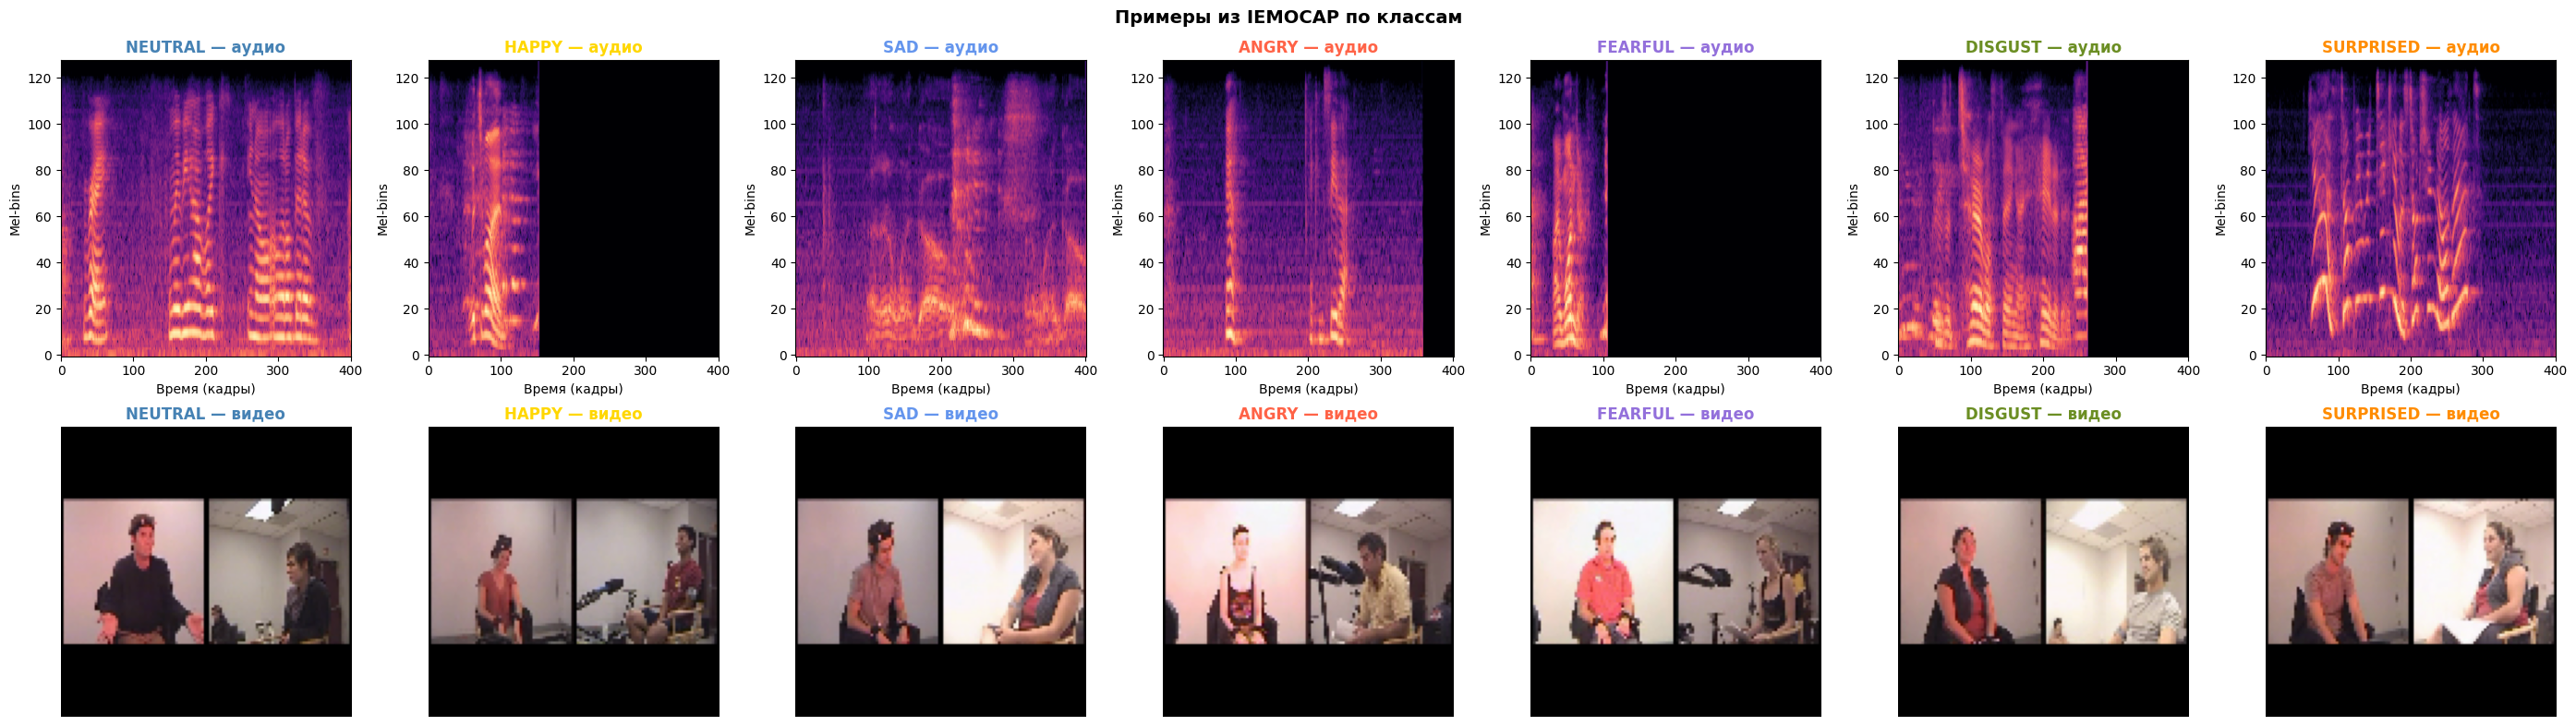


── Итог ──────────────────────────────────────────────────────────
Всего реплик:    5680
Классы (RAVDESS): ['neutral', 'happy', 'sad', 'angry', 'fearful', 'disgust', 'surprised']
  Эмоция        RAVDESS   Кол-во    Доля
  ------------------------------------
  neutral            01     1708   30.1%
  happy              03     1636   28.8%
  sad                04     1084   19.1%
  angry              05     1103   19.4%
  fearful            06       40    0.7%
  disgust            07        2    0.0%
  surprised          08      107    1.9%
Аудио формат:    log-mel (128 mel × T)
Видео формат:    8 кадров × 112×112 RGB
Сохранено в:     ../datasets/iemocap_processed


In [21]:
fig, axes = plt.subplots(2, 7, figsize=(28, 8))
emotions = list(LABEL2IDX.keys())   # 7 классов в порядке RAVDESS
colors   = [EMO_COLORS[e] for e in emotions]

for col, (emo, color) in enumerate(zip(emotions, colors)):
    subset = meta[meta['emotion'] == emo]
    row_sample = subset.sample(1, random_state=col).iloc[0]

    # Верхняя строка: log-mel спектрограмма
    mel = extract_log_mel(row_sample['audio_path'])
    axes[0, col].imshow(mel, aspect='auto', origin='lower', cmap='magma')
    axes[0, col].set_title(f'{emo.upper()} — аудио', color=color, fontweight='bold')
    axes[0, col].set_xlabel('Время (кадры)')
    axes[0, col].set_ylabel('Mel-bins')

    # Нижняя строка: наиболее выразительный видео-кадр (средний из сегмента)
    avi = avi_path(row_sample, IEMOCAP_ROOT)
    if os.path.exists(avi):
        frames = extract_frames(avi, row_sample['start'], row_sample['end'], n_frames=1)
        if frames is not None:
            axes[1, col].imshow(frames[0])
        else:
            axes[1, col].text(0.5, 0.5, 'нет кадра', ha='center', va='center', transform=axes[1,col].transAxes)
    else:
        axes[1, col].text(0.5, 0.5, 'нет AVI', ha='center', va='center', transform=axes[1,col].transAxes)
    axes[1, col].set_title(f'{emo.upper()} — видео', color=color, fontweight='bold')
    axes[1, col].axis('off')

plt.suptitle('Примеры из IEMOCAP по классам', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'samples.png'), dpi=150)
plt.show()

print('\n── Итог ──────────────────────────────────────────────────────────')
print(f'Всего реплик:    {len(meta)}')
print(f'Классы (RAVDESS): {list(LABEL2IDX.keys())}')
print(f'  {"Эмоция":<12} {"RAVDESS":>8}  {"Кол-во":>7}  {"Доля":>6}')
print(f'  {"-"*36}')
ravdess_id = {'neutral': '01', 'happy': '03', 'sad': '04',
              'angry': '05', 'fearful': '06', 'disgust': '07', 'surprised': '08'}
for emo, idx in LABEL2IDX.items():
    n = (meta['label'] == idx).sum()
    rid = ravdess_id.get(emo, '??')
    print(f'  {emo:<12} {rid:>8}  {n:>7}  {n/len(meta)*100:>5.1f}%')
print(f'Аудио формат:    log-mel ({N_MELS} mel × T)')
print(f'Видео формат:    {N_FRAMES} кадров × {FRAME_SIZE[0]}×{FRAME_SIZE[1]} RGB')
print(f'Сохранено в:     {SAVE_DIR}')